In [8]:
# imports 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:


# Load Diagnostics 

BASE_DIR = "data/diagnostics"

portfolio_names = [
    "equal_sleeve_combo",
    "inverse_vol_sleeve_combo",
    "scalar_weighted_sleeve_combo"
]

diagnostics = {}

for name in portfolio_names:
    diagnostics[name] = {
        "pnl": pd.read_parquet(f"{BASE_DIR}/{name}_pnl.parquet"),
        "turnover": pd.read_parquet(f"{BASE_DIR}/{name}_turnover.parquet"),
        "stats": pd.read_parquet(f"{BASE_DIR}/{name}_stats.parquet"),
        "returns": pd.read_parquet(f"{BASE_DIR}/{name}_returns.parquet")
    }

    # optional loads (only if exist)
    weights_path = f"{BASE_DIR}/{name}_weights.parquet"
    sleeve_alloc_path = f"{BASE_DIR}/{name}_sleeve_alloc.parquet"
    sleeve_pnls_path = f"{BASE_DIR}/{name}_sleeve_pnls.parquet"

    diagnostics[name]["weights"] = (
        pd.read_parquet(weights_path) if os.path.exists(weights_path) else None
    )

    diagnostics[name]["sleeve_alloc"] = (
        pd.read_parquet(sleeve_alloc_path) if os.path.exists(sleeve_alloc_path) else None
    )

    diagnostics[name]["sleeve_pnls"] = (
        pd.read_parquet(sleeve_pnls_path) if os.path.exists(sleeve_pnls_path) else None
    )

# combined stats table
all_stats_df = pd.concat(
    [diagnostics[name]["stats"] for name in portfolio_names],
    axis=0
)

all_stats_df

,GrossSharpe,NetSharpe,MaxDD,Turnover
equal_sleeve_combo,0.680876,0.592194,-0.045709,3.353380
inverse_vol_sleeve_combo,0.773134,0.595686,-0.028868,4.584806
scalar_weighted_sleeve_combo,0.788269,0.705360,-0.045705,3.351252


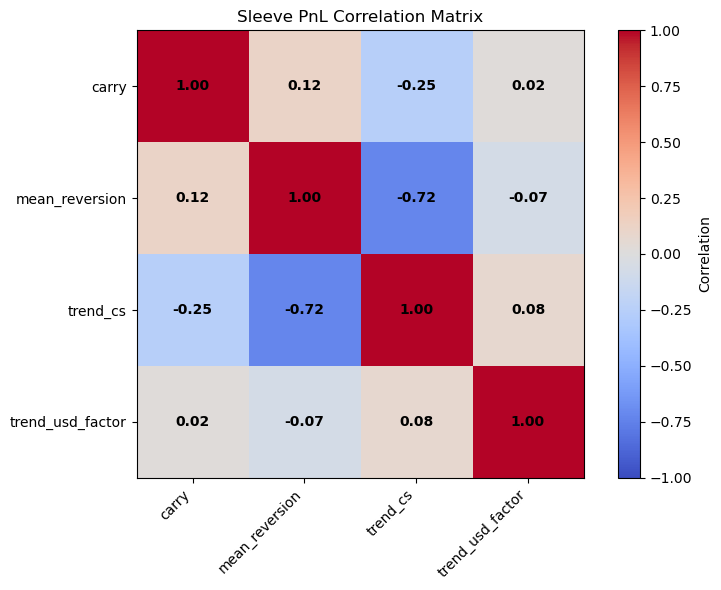

,carry,mean_reversion,trend_cs,trend_usd_factor
carry,1.000000,0.115708,-0.250282,0.020776
mean_reversion,0.115708,1.000000,-0.721448,-0.070180
trend_cs,-0.250282,-0.721448,1.000000,0.077890
trend_usd_factor,0.020776,-0.070180,0.077890,1.000000


In [10]:
# correlations

def sleeve_pnl_correlation_diagnostics(
    sleeve_pnls_df,
    method="pearson",
    plot=True
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # --- Clean input ---
    sleeve_pnls_df = sleeve_pnls_df.dropna(how="all").dropna()

    # --- Correlation matrix ---
    corr = sleeve_pnls_df.corr(method=method)

    # --- Remove diagonal for avg abs corr ---
    corr_no_diag = corr.copy()
    np.fill_diagonal(corr_no_diag.values, np.nan)

    avg_abs_corr = corr_no_diag.abs().mean().sort_values(ascending=False)

    if plot:
        plt.figure(figsize=(8, 6))

        im = plt.imshow(
            corr,
            cmap="coolwarm",
            vmin=-1,
            vmax=1
        )

        plt.colorbar(im, label="Correlation")

        plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
        plt.yticks(range(len(corr.index)), corr.index)

        plt.title("Sleeve PnL Correlation Matrix")

        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                val = corr.iloc[i, j]
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontweight="bold")

        plt.tight_layout()
        plt.show()

    return {
        "corr": corr,
        "avg_abs_corr": avg_abs_corr
    }

corr_diag = sleeve_pnl_correlation_diagnostics(
    sleeve_pnls_df=diagnostics["scalar_weighted_sleeve_combo"]["sleeve_pnls"],
    method="pearson",
    plot=True
)

corr_diag["corr"]

In [11]:
corr_diag["avg_abs_corr"]

trend_cs            0.349873
mean_reversion      0.302445
carry               0.128922
trend_usd_factor    0.056282
dtype: float64

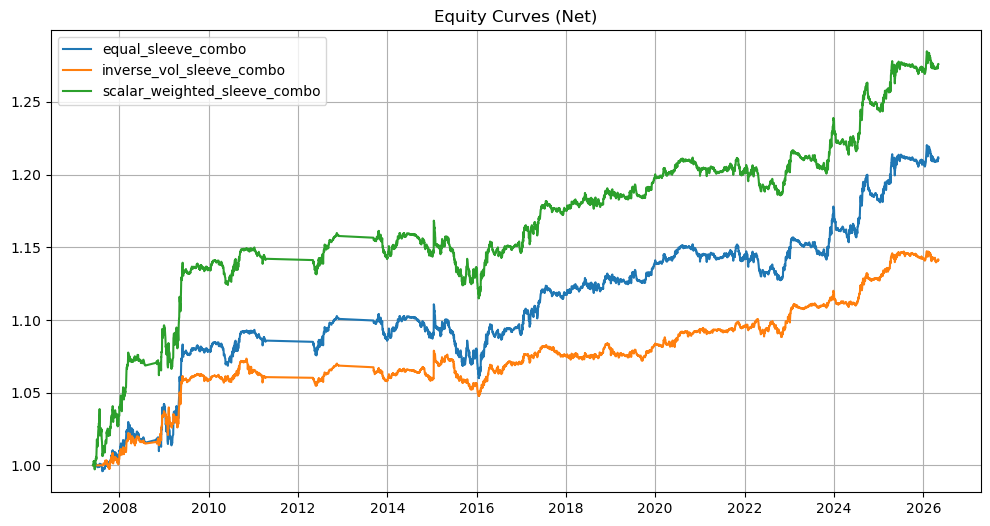

In [12]:
# --- Build equity curves ---
equity_curves = {}

for name, diag in diagnostics.items():
    pnl = diag["pnl"]["gross"]
    net_pnl = diag["pnl"]["net"]

    equity_curves[name] = pd.DataFrame({
        "gross": (1 + pnl).cumprod(),
        "net": (1 + net_pnl).cumprod()
    })

# --- Plot NET equity curves (primary) ---
plt.figure(figsize=(12, 6))

for name, eq in equity_curves.items():
    plt.plot(eq.index, eq["net"], label=name)

plt.title("Equity Curves (Net)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# ROLLING SHARPE / ROLLING VOL / DRAWDOWN

import numpy as np
import matplotlib.pyplot as plt

ROLLING_WINDOW = 252

def rolling_diagnostics(pnl, window=252):
    rolling_mean = pnl.rolling(window).mean()
    rolling_vol = pnl.rolling(window).std() * np.sqrt(252)
    rolling_sharpe = rolling_mean / pnl.rolling(window).std() * np.sqrt(252)

    equity = (1 + pnl).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1

    return pd.DataFrame({
        "rolling_sharpe": rolling_sharpe,
        "rolling_vol": rolling_vol,
        "drawdown": drawdown
    })


rolling_diag = {}

for name, diag in diagnostics.items():
    net_pnl = diag["pnl"]["net"].dropna()
    rolling_diag[name] = rolling_diagnostics(net_pnl, window=ROLLING_WINDOW)

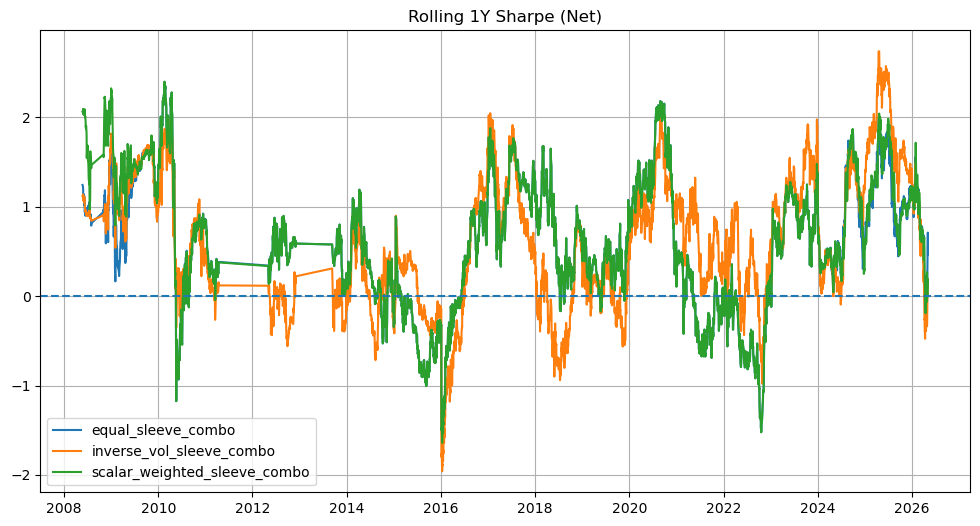

In [14]:
# --- Rolling Sharpe ---
plt.figure(figsize=(12, 6))

for name, rd in rolling_diag.items():
    plt.plot(rd.index, rd["rolling_sharpe"], label=name)

plt.axhline(0, linestyle="--")
plt.title("Rolling 1Y Sharpe (Net)")
plt.legend()
plt.grid(True)
plt.show()

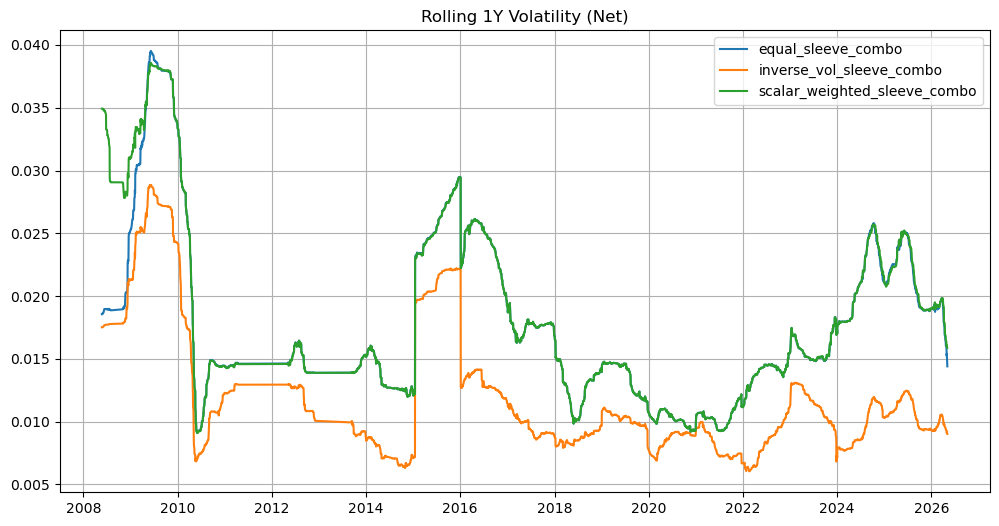

In [15]:
# --- Rolling Vol ---
plt.figure(figsize=(12, 6))

for name, rd in rolling_diag.items():
    plt.plot(rd.index, rd["rolling_vol"], label=name)

plt.title("Rolling 1Y Volatility (Net)")
plt.legend()
plt.grid(True)
plt.show()

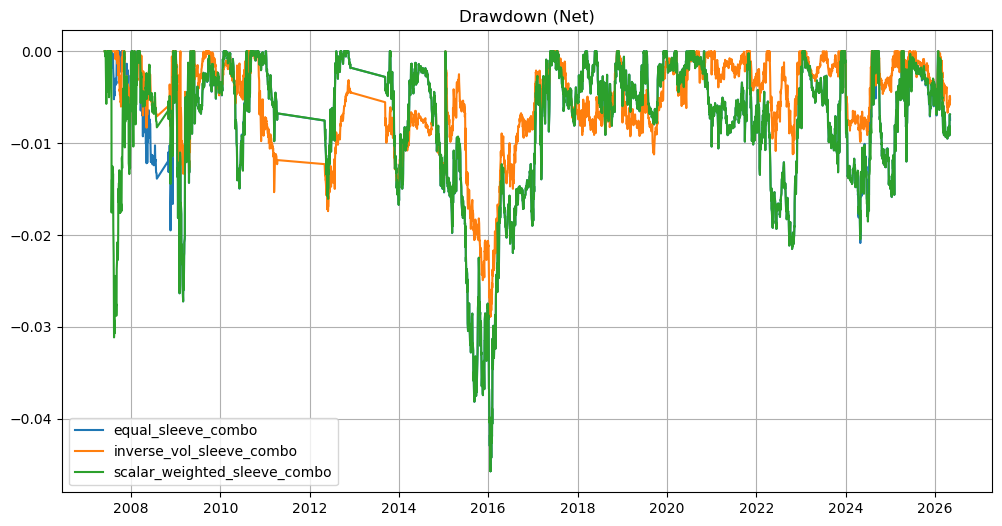

In [16]:
# --- Drawdown ---
plt.figure(figsize=(12, 6))

for name, rd in rolling_diag.items():
    plt.plot(rd.index, rd["drawdown"], label=name)

plt.title("Drawdown (Net)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# SUBPERIOD PERFORMANCE

def compute_subperiod_stats(pnl, n_splits=3):
    pnl = pnl.dropna()

    # split via index positions (no numpy on Series)
    idx_splits = np.array_split(np.arange(len(pnl)), n_splits)

    results = []

    for i, idx in enumerate(idx_splits):
        sub = pnl.iloc[idx]

        if len(sub) < 50:
            continue

        std = sub.std()
        sharpe = sub.mean() / std * np.sqrt(252) if std > 0 else np.nan

        equity = (1 + sub).cumprod()
        dd = equity / equity.cummax() - 1
        max_dd = dd.min()

        results.append({
            "Period": f"P{i+1}",
            "Sharpe": sharpe,
            "MaxDD": max_dd,
            "Obs": len(sub)
        })

    return pd.DataFrame(results)


subperiod_results = {}

for name, diag in diagnostics.items():
    pnl = diag["pnl"]["net"]
    subperiod_results[name] = compute_subperiod_stats(pnl, n_splits=3)


# --- Combine for view ---
subperiod_table = pd.concat(
    {name: df.set_index("Period") for name, df in subperiod_results.items()},
    axis=0
)

subperiod_table

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Sharpe     MaxDD   Obs
                             Period                          
equal_sleeve_combo           P1      0.706963 -0.027228  1462
                             P2      0.526844 -0.036726  1462
                             P3      0.524237 -0.021518  1461
inverse_vol_sleeve_combo     P1      0.694172 -0.017399  1462
                             P2      0.330636 -0.026438  1462
                             P3      0.786288 -0.011206  1461
scalar_weighted_sleeve_combo P1      0.971997 -0.031140  1458
                             P2      0.524107 -0.036768  1458
                             P3      0.536261 -0.021519  1458

In [18]:
# SLEEVE CONTRIBUTION

def compute_sleeve_contribution(diag):
    pnl = diag["pnl"]["net"]
    sleeve_pnls = diag["sleeve_pnls"]

    # align
    common_idx = pnl.index.intersection(sleeve_pnls.index)
    pnl = pnl.loc[common_idx]
    sleeve_pnls = sleeve_pnls.loc[common_idx]

    # contribution = mean return per sleeve
    contrib = sleeve_pnls.mean() * 252

    # normalize to % contribution
    total = contrib.sum()
    pct_contrib = contrib / total if total != 0 else contrib * np.nan

    return pd.DataFrame({
        "AnnReturn": contrib,
        "PctContribution": pct_contrib
    })


sleeve_contributions = {}

for name, diag in diagnostics.items():
    if diag["sleeve_pnls"] is not None:
        sleeve_contributions[name] = compute_sleeve_contribution(diag)

# view one
sleeve_contributions["scalar_weighted_sleeve_combo"]

,AnnReturn,PctContribution
carry,0.029093,0.559780
mean_reversion,0.010355,0.199243
trend_cs,0.003560,0.068496
trend_usd_factor,0.008964,0.172482


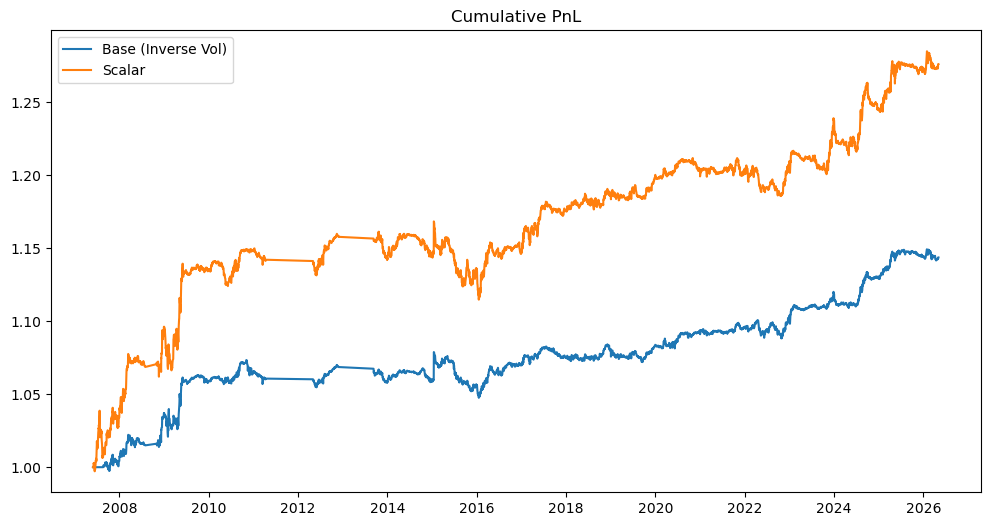

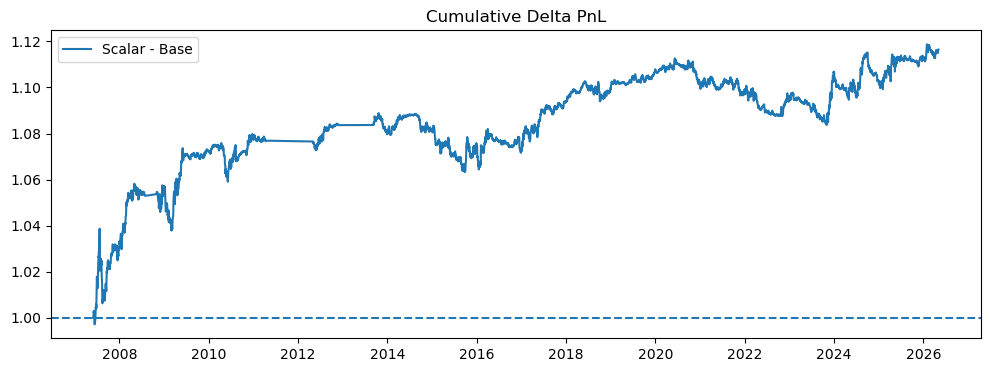

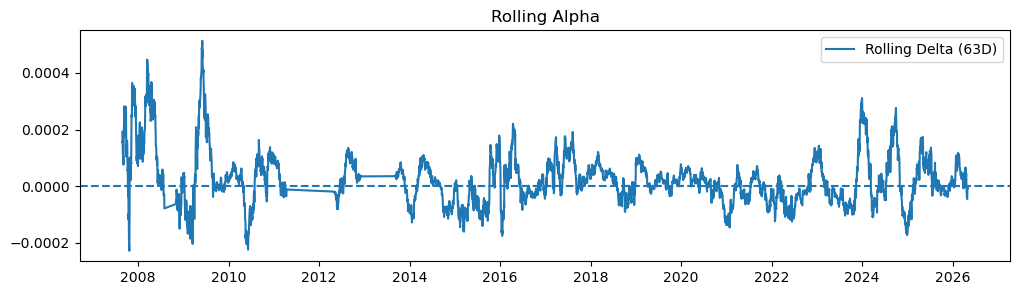

In [19]:
# Delta 

base_pnl = diagnostics["inverse_vol_sleeve_combo"]["pnl"]["net"]
scalar_pnl = diagnostics["scalar_weighted_sleeve_combo"]["pnl"]["net"]

common_idx = base_pnl.index.intersection(scalar_pnl.index)

base_pnl = base_pnl.loc[common_idx]
scalar_pnl = scalar_pnl.loc[common_idx]

# cumulative
base_cum = (1 + base_pnl).cumprod()
scalar_cum = (1 + scalar_pnl).cumprod()

# delta pnl
delta_pnl = scalar_pnl - base_pnl
delta_cum = (1 + delta_pnl).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(base_cum, label="Base (Inverse Vol)")
plt.plot(scalar_cum, label="Scalar")
plt.legend()
plt.title("Cumulative PnL")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(delta_cum, label="Scalar - Base")
plt.axhline(1.0, linestyle="--")
plt.title("Cumulative Delta PnL")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(delta_pnl.rolling(63).mean(), label="Rolling Delta (63D)")
plt.axhline(0, linestyle="--")
plt.title("Rolling Alpha")
plt.legend()
plt.show()